# MLOps Workshop: Datenvorverarbeitung

## 1. Einführung
In diesem Notebook werden wir uns mit der Vorverarbeitung unseres Telco Customer Churn Datensatzes beschäftigen. Wir werden uns auf Datenbereinigung und Feature Engineering konzentrieren.

## 2. Lernziele
Nach Abschluss dieses Notebooks werden Sie:
- Methoden zur systematischen Datenbereinigung beherrschen
- Feature Engineering Techniken anwenden können
- Eine vollständige Preprocessing Pipeline erstellen können
- Preprocessing Best Practices im MLOps-Kontext verstehen

## 3. Setup und Datenvorbereitung


In [66]:
# Benötigte Bibliotheken importieren
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import unittest



# Matplotlib für deutsche Beschriftungen konfigurieren
plt.rcParams['axes.formatter.use_locale'] = True


In [67]:
# Datensatz laden
df = pd.read_csv('../data/processed/loan_data_validated.csv')
print(f"Datensatz geladen: {df.shape} (Zeilen, Spalten)")


Datensatz geladen: (9578, 14) (Zeilen, Spalten)


## 2. Feature Engineering



In [68]:
# Feature-Typen definieren 
categorical_features = ["purpose"]

numerical_features = [
    "int.rate",
    "installment",
    "log.annual.inc",
    "dti",
    "fico",
    "days.with.cr.line",
    "revol.bal",
    "revol.util",
    "inq.last.6mths",
    "delinq.2yrs",
    "pub.rec"
]

binary_features = ["credit.policy"]

target = "not.fully.paid"

### 5.2 Feature-Generierung
Erstellung neuer Features

1. Identifizieren Sie mindestens drei geschäftsrelevante neue Features
2. Dokumentieren Sie die Bedeutung jedes neuen Features
3. Implementieren Sie die Feature-Generierung
4. Analysieren Sie die neuen Features


In [69]:
# Neues Feature: Debt Burden Ratio  = (Monatliche Rate * DTI) / Logarithmus des Jahreseinkommens

df["debt_burden_ratio"] = df["installment"] * df["dti"] / np.exp(df["log.annual.inc"])

# Schuldenbelastung relativ zur Kreditwürdigkeit (FICO-Score)

df["dti_to_fico"] = df["dti"] / df["fico"]

# Zinsniveau relativ zur Kreditwürdigkeit

df["int_rate_to_fico"] = df["int.rate"] / df["fico"]

# Kreditkartenschulden relativ zum Einkommen
df["revol_bal_to_inc"] = df["revol.bal"] / np.exp(df["log.annual.inc"])

df.head(5)

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,debt_burden_ratio,dti_to_fico,int_rate_to_fico,revol_bal_to_inc
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,0.190010,0.026431,0.000161,0.339459
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,0.050173,0.020212,0.000151,0.517277
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,0.133331,0.017053,0.000199,0.109719
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,0.015470,0.011376,0.000142,0.396082
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,0.019068,0.022444,0.000214,0.058663


In [70]:
# Durchschnittliche Werte der neuen Features für Kreditnehmer mit und ohne Zahlungsausfall vergleichen
new_features = [
    "debt_burden_ratio",
    "dti_to_fico",
    "int_rate_to_fico",
    "revol_bal_to_inc"
]

df.groupby("not.fully.paid")[new_features].mean()

,debt_burden_ratio,dti_to_fico,int_rate_to_fico,revol_bal_to_inc
not.fully.paid,,,,
0,0.071290,0.017687,0.000171,0.228733
1,0.081478,0.019036,0.000191,0.270128


Die Analyse der neuen Features zeigt, dass Kreditnehmer mit Zahlungsausfall (not.fully.paid = 1) im Durchschnitt höhere Werte in allen vier generierten Merkmalen aufweisen. Besonders revol_bal_to_inc und debt_burden_ratio sind erhöht. Das deutet darauf hin, dass eine höhere finanzielle Belastung und Verschuldung mit einem erhöhten Ausfallrisiko zusammenhängen. Die neuen Features liefern damit zusätzliche, geschäftsrelevante Informationen für das Modell.

In [71]:
df[new_features + ["not.fully.paid"]].corr()["not.fully.paid"]

debt_burden_ratio    0.057909
dti_to_fico          0.049672
int_rate_to_fico     0.164554
revol_bal_to_inc     0.056292
not.fully.paid       1.000000
Name: not.fully.paid, dtype: float64

Die Korrelationsanalyse zeigt, dass alle neu erzeugten Features einen positiven Zusammenhang mit der Zielvariable not.fully.paid aufweisen. Besonders int_rate_to_fico zeigt die stärkste Korrelation und könnte daher ein hilfreicher Indikator für das Ausfallrisiko sein.

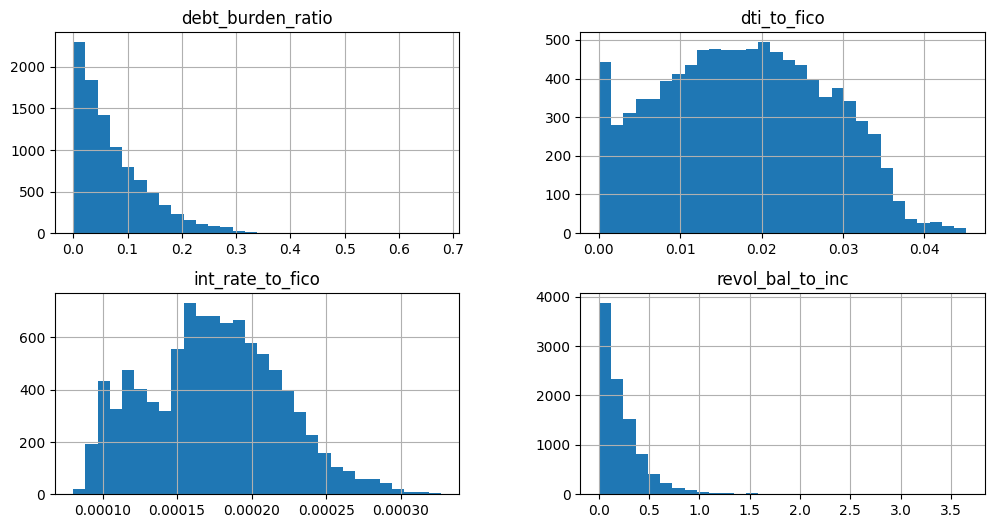

In [72]:
# Verteilung der neuen Features visualisieren

df[new_features].hist(figsize=(12,6), bins=30)
plt.show()

Die Histogramme zeigen die Verteilung der neu erzeugten Features. Einige Variablen wie debt_burden_ratio und revol_bal_to_inc weisen eine rechtsschiefe Verteilung auf, was bei Finanzdaten typisch ist. Die meisten Werte liegen im unteren Bereich, während einige wenige Beobachtungen höhere Werte aufweisen. Insgesamt erscheinen die Werte plausibel und enthalten keine offensichtlich fehlerhaften Extremwerte.

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


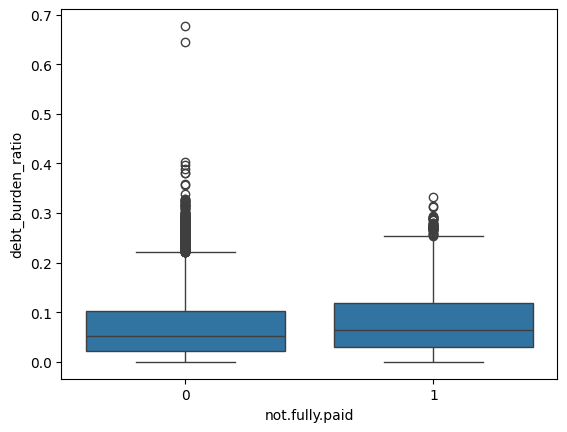

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


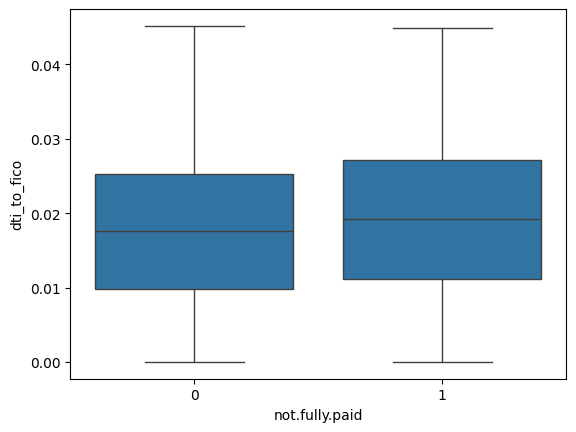

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


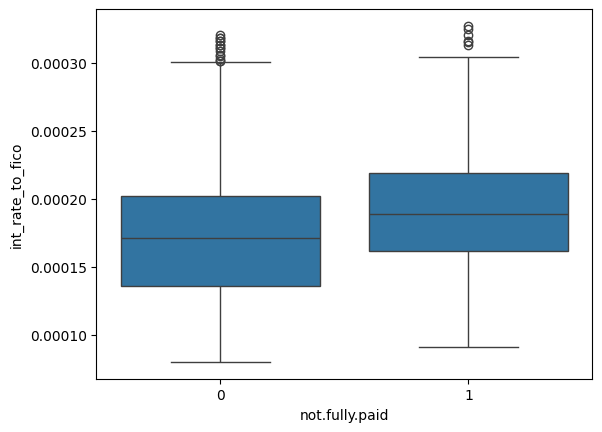

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


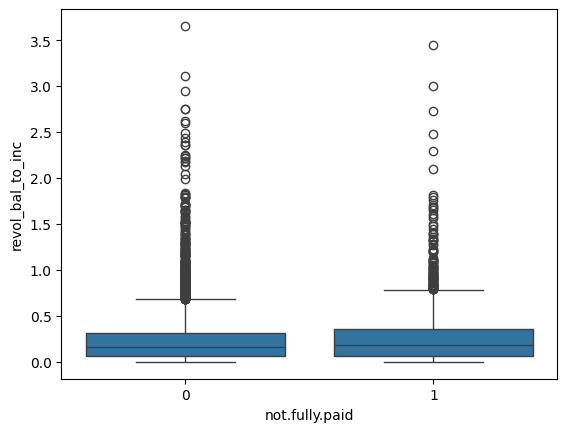

In [73]:
# Boxplots der neuen Features nach Zielvariable

for feature in new_features:
    sns.boxplot(x="not.fully.paid", y=feature, data=df)
    plt.show()

Die Boxplots zeigen Unterschiede der neuen Features zwischen Kreditnehmern, die ihren Kredit vollständig zurückgezahlt haben (not.fully.paid = 0), und solchen mit Zahlungsausfall (not.fully.paid = 1). Insgesamt sind die Medianwerte bei der Gruppe mit Zahlungsausfall leicht höher, insbesondere bei int_rate_to_fico, revol_bal_to_inc und debt_burden_ratio. Dies deutet darauf hin, dass höhere Zinssätze relativ zur Bonität, höhere Kreditkartenschulden im Verhältnis zum Einkommen sowie eine höhere finanzielle Belastung tendenziell mit einem höheren Ausfallrisiko verbunden sind. Die Features enthalten somit zusätzliche Informationen, die für ein Modell zur Vorhersage von Zahlungsausfällen relevant sein können.

### Zusammenfassung des Feature-Generierung

Im Rahmen des Feature Engineerings wurden vier neue, geschäftsrelevante Features erstellt, die unterschiedliche Aspekte des Kreditrisikos abbilden. Die anschließende Analyse anhand von Mittelwerten, Korrelationen, Histogrammen und Boxplots zeigt, dass diese Merkmale Unterschiede zwischen Kreditnehmern mit und ohne Zahlungsausfall sichtbar machen. Damit liefern die neuen Features zusätzliche Informationen, die für die spätere Modellierung der Zahlungsfähigkeit genutzt werden können.

## 6. Preprocessing Pipeline

**Übung 5: End-to-End Preprocessing Pipeline**
1. Erstellen Sie eine Pipeline-Klasse, die alle Preprocessing-Schritte vereint
2. Implementieren Sie Methoden für:
   - Datenbereinigung
   - Feature Engineering
   - Kategorisches Encoding
   - Feature Scaling
3. Speichern Sie die verarbeiteten Daten
4. Dokumentieren Sie die Pipeline


In [74]:
import logging
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


class PreprocessingPipeline:

    def __init__(self):
        self.scaler = StandardScaler()
        self.categorical_columns = ["purpose"]
        self.target_column = "not.fully.paid"
        logger.info("Pipeline wurde initialisiert")

    def clean_data(self, df):
        logger.info("Starte Datenbereinigung")

        try:
            df = df.copy()
            df = df.dropna()
            df = df.drop_duplicates()

            logger.info("Datenbereinigung abgeschlossen")
            return df

        except Exception as e:
            logger.error(f"Fehler bei clean_data: {e}")
            raise

    def engineer_features(self, df):
        logger.info("Feature Engineering gestartet")

        try:
            df = df.copy()

            df["debt_burden_ratio"] = df["installment"] * df["dti"] / np.exp(df["log.annual.inc"])
            df["dti_to_fico"] = df["dti"] / df["fico"]
            df["int_rate_to_fico"] = df["int.rate"] / df["fico"]
            df["revol_bal_to_inc"] = df["revol.bal"] / np.exp(df["log.annual.inc"])

            logger.info("Neue Features wurden erstellt")
            return df

        except Exception as e:
            logger.error(f"Fehler beim Feature Engineering: {e}")
            raise

    def encode_categorical(self, df):
        logger.info("Encoding der kategorialen Variablen")

        try:
            df = df.copy()
            df = pd.get_dummies(
                df,
                columns=self.categorical_columns,
                drop_first=True,
                dtype=int
            )

            logger.info("Encoding abgeschlossen")
            return df

        except Exception as e:
            logger.error(f"Fehler beim Encoding: {e}")
            raise

    def save_data(self, df, filepath):
        logger.info(f"Speichere Daten unter {filepath}")

        try:
            df.to_csv(filepath, index=False)
            logger.info("Daten erfolgreich gespeichert")
            return df

        except Exception as e:
            logger.error(f"Fehler beim Speichern der Daten: {e}")
            raise

    def transform(self, df):
        logger.info("Pipeline Verarbeitung gestartet")

        df = self.clean_data(df)
        df = self.engineer_features(df)
        df = self.encode_categorical(df)
        df = self.save_data(df, "../data/processed/loan_data_preprocessed.csv")

        logger.info("Pipeline Verarbeitung abgeschlossen")
        return df

In [75]:
df = pd.read_csv("../data/processed/loan_data_validated.csv")

pipeline = PreprocessingPipeline()

df_clean = pipeline.transform(df)


INFO:__main__:Pipeline wurde initialisiert
INFO:__main__:Pipeline Verarbeitung gestartet
INFO:__main__:Starte Datenbereinigung
INFO:__main__:Datenbereinigung abgeschlossen


INFO:__main__:Feature Engineering gestartet
INFO:__main__:Neue Features wurden erstellt
INFO:__main__:Encoding der kategorialen Variablen
INFO:__main__:Encoding abgeschlossen
INFO:__main__:Speichere Daten unter ../data/processed/loan_data_preprocessed.csv
INFO:__main__:Daten erfolgreich gespeichert
INFO:__main__:Pipeline Verarbeitung abgeschlossen


In [76]:
df = pd.read_csv("../data/processed/loan_data_preprocessed.csv")
df.head()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,debt_burden_ratio,dti_to_fico,int_rate_to_fico,revol_bal_to_inc,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,0.190010,0.026431,0.000161,0.339459,0,1,0,0,0,0
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,0.050173,0.020212,0.000151,0.517277,1,0,0,0,0,0
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,0.133331,0.017053,0.000199,0.109719,0,1,0,0,0,0
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,0.015470,0.011376,0.000142,0.396082,0,1,0,0,0,0
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,0.019068,0.022444,0.000214,0.058663,1,0,0,0,0,0


In [77]:
class TestPreprocessingPipeline(unittest.TestCase):

    def setUp(self):
        self.pipeline = PreprocessingPipeline()

    def test_engineer_features(self):
        df = pd.DataFrame({
            "credit.policy": [1, 1],
            "purpose": ["credit_card", "debt_consolidation"],
            "int.rate": [0.1, 0.15],
            "installment": [100, 200],
            "log.annual.inc": [10, 11],
            "dti": [5, 10],
            "fico": [700, 650],
            "days.with.cr.line": [1000, 2000],
            "revol.bal": [5000, 6000],
            "revol.util": [30, 40],
            "inq.last.6mths": [1, 2],
            "delinq.2yrs": [0, 1],
            "pub.rec": [0, 0],
            "not.fully.paid": [0, 1]
        })

        df_result = self.pipeline.engineer_features(df)

        self.assertIn("debt_burden_ratio", df_result.columns)
        self.assertIn("dti_to_fico", df_result.columns)
        self.assertIn("int_rate_to_fico", df_result.columns)
        self.assertIn("revol_bal_to_inc", df_result.columns)



In [84]:
# Unittest ausführen

unittest.main(argv=[''], exit=False)



INFO:__main__:Pipeline wurde initialisiert
INFO:__main__:Feature Engineering gestartet
INFO:__main__:Neue Features wurden erstellt
.
----------------------------------------------------------------------
Ran 1 test in 0.004s

OK
